# Pipeline de ML, Otimização e Decisão de Manutenção
### Complexo Petroquímico — `petrochemical_advanced_data.csv`

**Pergunta de negócio 1:** qual configuração operacional reduz o custo / a intensidade energética *mantendo* a produção e as restrições operacionais?

**Pergunta de negócio 2:** devemos realizar manutenção? Essa decisão poderia ser automatizada?

---

| Seção | Entrega do enunciado |
|---|---|
| 1 | Entendimento do negócio |
| 2 | EDA |
| 3 | Feature engineering |
| 4 | **Target leakage** (energia) |
| 5 | Machine Learning — 2 modelos por target |
| 6 | Otimização |
| 7 | Cenários de manutenção |
| 8 | Análise de custo/risco e automação |
| 9 | Pipeline final |
| 10 | Tabela final de decisão |
| 11 | Conclusão |
| 12 | Export para a API / apresentação |


## 0. Setup


In [2]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")

# torna o pacote src/ importável a partir de notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import src.config as cfg

print("Python:", sys.version.split()[0])
print("Raiz do projeto:", ROOT)


Python: 3.12.10
Raiz do projeto: c:\GitHub_jffdevbr\checkpoint5_leandro


In [3]:
df = pd.read_csv(cfg.DATA_RAW, parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(df.shape)
print(f"Período: {df.Timestamp.min()}  ->  {df.Timestamp.max()}")
df.head()


(10000, 16)
Período: 2020-01-01 00:00:00  ->  2024-07-24 12:00:00


,Timestamp,Unit_Name,Catalyst_Type,Catalyst_Age_Days,Sensor_Health_Index,Vibration_Level_mm_s,Valve_Opening_Percent,Feedstock_Flow_m3h,Reactor_Temp_C,Reactor_Pressure_Bar,Electricity_MWh,Natural_Gas_m3h,Steam_Tons_h,Ambient_Temp_C,Product_Yield_Tons,Energy_Intensity
0,2020-01-01 00:00:00,Methanol_Complex_03,Iron_Standard_V5,228,0.9371,3.5710,42.2678,640.2060,822.7945,30.6686,17.2057,"4,161.0730",53.0997,-9.2433,107.9938,1.9221
1,2020-01-01 04:00:00,Ethylene_Plant_01,Cobalt_Premium_Z2,298,0.7410,1.4459,40.5605,589.3432,788.9340,29.6742,20.0761,"4,896.9311",53.1076,16.6929,78.6073,3.0998
2,2020-01-01 08:00:00,Methanol_Complex_03,Cobalt_Premium_Z2,291,0.8086,5.0400,70.7702,560.4219,777.9860,30.4054,15.5592,"3,553.3127",59.7059,6.3103,81.5676,2.2114
3,2020-01-01 12:00:00,Methanol_Complex_03,Platinum_Base_X1,67,0.6713,8.1189,89.6138,666.9878,764.7108,33.0564,17.5461,"4,985.7114",72.9536,0.5864,80.6001,2.9487
4,2020-01-01 16:00:00,Ethylene_Plant_01,Cobalt_Premium_Z2,251,0.8272,4.8401,39.0654,634.5843,769.0897,27.5199,23.3172,"3,505.9653",86.3124,23.1502,94.4818,2.1872


## 1. Entendimento do negócio

### 1.1 Objetivo da operação

O trabalho parte de duas perguntas de negócio (ver a abertura do notebook), e cada uma é respondida por um dos dois targets:

- **Pergunta 1 — qual configuração operacional reduz o custo/a intensidade energética mantendo a produção?** Respondida pelo modelo de `Energy_Intensity`: prevemos a intensidade energética esperada de uma configuração e usamos isso no otimizador (seção 6) para buscar o menor custo sem violar a produção mínima.
- **Pergunta 2 — devemos realizar manutenção?** Respondida (em parte) pelo modelo de `Product_Yield_Tons`: com a vazão de matéria-prima (`Feedstock_Flow_m3h`) mantida, uma queda de produção é sintoma de degradação do equipamento (`Sensor_Health_Index` caindo) — o modelo de Yield funciona como termômetro da saúde do equipamento, alimentando a decisão de manutenção (seção 7).

Por isso os dois modelos fazem sentido, mesmo sabendo (seções 2.1.b–2.1.f) que os dois targets não são estatisticamente independentes neste dataset: `Energy_Intensity` é derivada aritmeticamente de `Product_Yield_Tons` e do consumo de energia (identidade confirmada formalmente na seção 4). Isso não invalida os dois modelos — cada um continua respondendo a uma pergunta de negócio diferente —, mas significa que, neste dataset, "reduzir a intensidade energética" se dá sobretudo por "aumentar a produção" (via `Feedstock_Flow_m3h` e a saúde do equipamento), e não por uma alavanca de eficiência energética independente.

### 1.2 Tabela de classificação das variáveis

A célula abaixo gera a tabela a partir de `src/config.py`, então a classificação fica **versionada e usada de verdade pelo pipeline** — não é só uma tabela decorativa no relatório.

In [4]:
def tabela_variaveis(df: pd.DataFrame) -> pd.DataFrame:
    classe = {}
    for c in cfg.CONTROLAVEIS:      classe[c] = "Controlável (decisão)"
    for c in cfg.ESTADO:            classe[c] = "Estado (equipamento)"
    for c in cfg.EXTERNAS:          classe[c] = "Externa (não controlável)"
    for c in cfg.CONSUMO_ENERGIA:   classe[c] = "Consumo medido (RISCO DE LEAKAGE)"
    for c in cfg.TARGETS:           classe[c] = "TARGET"
    classe["Timestamp"] = "Índice temporal"

    descricao = {
        "Timestamp": "Instante da leitura, em grade fixa de 4 em 4 horas.",
        "Unit_Name": "Planta/unidade industrial que gerou a leitura (3 plantas).",
        "Catalyst_Type": "Tipo de catalisador em uso no reator.",
        "Catalyst_Age_Days": "Idade do catalisador atualmente em uso, em dias.",
        "Sensor_Health_Index": "Índice de saúde dos sensores/instrumentação da planta (0-1).",
        "Vibration_Level_mm_s": "Nível de vibração medido no equipamento; sinal de desgaste mecânico.",
        "Valve_Opening_Percent": "Abertura da válvula de controle de processo.",
        "Feedstock_Flow_m3h": "Vazão de matéria-prima alimentada ao reator.",
        "Reactor_Temp_C": "Temperatura de operação do reator (setpoint).",
        "Reactor_Pressure_Bar": "Pressão de operação do reator (setpoint).",
        "Ambient_Temp_C": "Temperatura ambiente no momento da leitura; não controlável.",
        "Electricity_MWh": "Consumo de eletricidade no período; usar com cautela (risco de leakage).",
        "Natural_Gas_m3h": "Consumo de gás natural; usar com cautela (risco de leakage).",
        "Steam_Tons_h": "Consumo/geração de vapor; usar com cautela (risco de leakage).",
        "Product_Yield_Tons": "Produção de produto obtida na janela de 4h — Target 1 (maximizar).",
        "Energy_Intensity": "Energia consumida por tonelada produzida — Target 2 (minimizar); provável métrica derivada.",
    }

    linhas = []
    for c in df.columns:
        s = df[c]
        linhas.append({
            "Variavel": c,
            "Classificacao": classe.get(c, "NÃO CLASSIFICADA"),
            "Descricao": descricao.get(c, ""),
            "Tipo": str(s.dtype),
            "Min": s.min() if pd.api.types.is_numeric_dtype(s) else "-",
            "Max": s.max() if pd.api.types.is_numeric_dtype(s) else "-",
            "Nulos": int(s.isna().sum()),
        })
    return pd.DataFrame(linhas)

tab_vars = tabela_variaveis(df)
tab_vars


,Variavel,Classificacao,Descricao,Tipo,Min,Max,Nulos
0,Timestamp,Índice temporal,"Instante da leitura, em grade fixa de 4 em 4 h...",datetime64[us],-,-,0
1,Unit_Name,Externa (não controlável),Planta/unidade industrial que gerou a leitura ...,str,-,-,0
2,Catalyst_Type,Externa (não controlável),Tipo de catalisador em uso no reator.,str,-,-,0
3,Catalyst_Age_Days,Estado (equipamento),"Idade do catalisador atualmente em uso, em dias.",int64,1,364,0
4,Sensor_Health_Index,Estado (equipamento),Índice de saúde dos sensores/instrumentação da...,float64,0.5602,0.9999,0
5,Vibration_Level_mm_s,Estado (equipamento),Nível de vibração medido no equipamento; sinal...,float64,0.5008,8.4992,0
6,Valve_Opening_Percent,Controlável (decisão),Abertura da válvula de controle de processo.,float64,20.0070,94.9857,0
7,Feedstock_Flow_m3h,Controlável (decisão),Vazão de matéria-prima alimentada ao reator.,float64,341.0339,758.5144,0
8,Reactor_Temp_C,Controlável (decisão),Temperatura de operação do reator (setpoint).,float64,675.8242,966.3611,0
9,Reactor_Pressure_Bar,Controlável (decisão),Pressão de operação do reator (setpoint).,float64,20.6683,43.5803,0


### 1.3 Restrições e regras de negócio

Preencher (cada uma precisa virar código depois, na seção 6):

| # | Restrição / regra | Como vira código |
|---|---|---|
| R1 | Produção ≥ `PRODUCAO_MINIMA_TON` | restrição do otimizador |
| R2 | Variáveis de decisão dentro da faixa operacional segura | `bounds` |
| R3 | Vibração acima de `LIMITE_VIBRACAO_CRITICO` → manutenção obrigatória | regra determinística, sobrepõe o modelo |
| R4 | `Sensor_Health_Index` < limite → decisão **não** pode ser automática (dado não confiável) | *gate* de automação |
| R5 | ... | |

> Dica de nota: R4 é a regra que mais impressiona na apresentação — ela conecta a seção 1 com a seção 8 (automação). Se o sensor que alimenta o modelo está degradado, a saída do modelo não deve ser executada sozinha.


## 2. EDA

Objetivo aqui **não** é encher de gráfico. São 4 perguntas:

1. Como os targets se distribuem e existe outlier/regime distinto?
2. As unidades (`Unit_Name`) e catalisadores (`Catalyst_Type`) se comportam como populações diferentes? *(se sim, o modelo precisa dessa informação — e talvez a otimização deva ser por unidade)*
3. Existe degradação ao longo do tempo (idade do catalisador / vibração vs. eficiência)? *(é isso que justifica manutenção)*
4. Quais controláveis realmente movem os targets?


In [5]:
display(df.describe().T)
print(df.dtypes)
print("\nDuplicatas:", df.duplicated().sum())
print("Nulos por coluna:\n", df.isna().sum()[lambda s: s > 0])


,count,mean,min,25%,50%,75%,max,std
Timestamp,10000,2022-04-13 06:00:00,2020-01-01 00:00:00,2021-02-20 15:00:00,2022-04-13 06:00:00,2023-06-03 21:00:00,2024-07-24 12:00:00,NaN
Catalyst_Age_Days,"10,000.0000",181.1290,1.0000,89.0000,180.0000,273.0000,364.0000,105.4074
Sensor_Health_Index,"10,000.0000",0.8092,0.5602,0.7311,0.8004,0.9019,0.9999,0.1102
Vibration_Level_mm_s,"10,000.0000",4.4749,0.5008,2.4985,4.4717,6.4630,8.4992,2.3083
Valve_Opening_Percent,"10,000.0000",57.6999,20.0070,39.0138,57.5899,76.4929,94.9857,21.6034
Feedstock_Flow_m3h,"10,000.0000",550.7199,341.0339,510.2378,550.7272,591.5501,758.5144,59.8924
Reactor_Temp_C,"10,000.0000",819.4520,675.8242,792.8757,819.0984,846.3069,966.3611,40.2279
Reactor_Pressure_Bar,"10,000.0000",31.9857,20.6683,29.9536,31.9546,34.0077,43.5803,2.9988
Electricity_MWh,"10,000.0000",22.5000,15.0050,18.7230,22.5377,26.1873,29.9987,4.3200
Natural_Gas_m3h,"10,000.0000","4,092.2463","3,012.4504","3,591.0163","4,098.9851","4,586.3399","5,180.9316",578.2615


Timestamp                datetime64[us]
Unit_Name                           str
Catalyst_Type                       str
Catalyst_Age_Days                 int64
Sensor_Health_Index             float64
Vibration_Level_mm_s            float64
Valve_Opening_Percent           float64
Feedstock_Flow_m3h              float64
Reactor_Temp_C                  float64
Reactor_Pressure_Bar            float64
Electricity_MWh                 float64
Natural_Gas_m3h                 float64
Steam_Tons_h                    float64
Ambient_Temp_C                  float64
Product_Yield_Tons              float64
Energy_Intensity                float64
dtype: object

Duplicatas: 0
Nulos por coluna:
 Series([], dtype: int64)


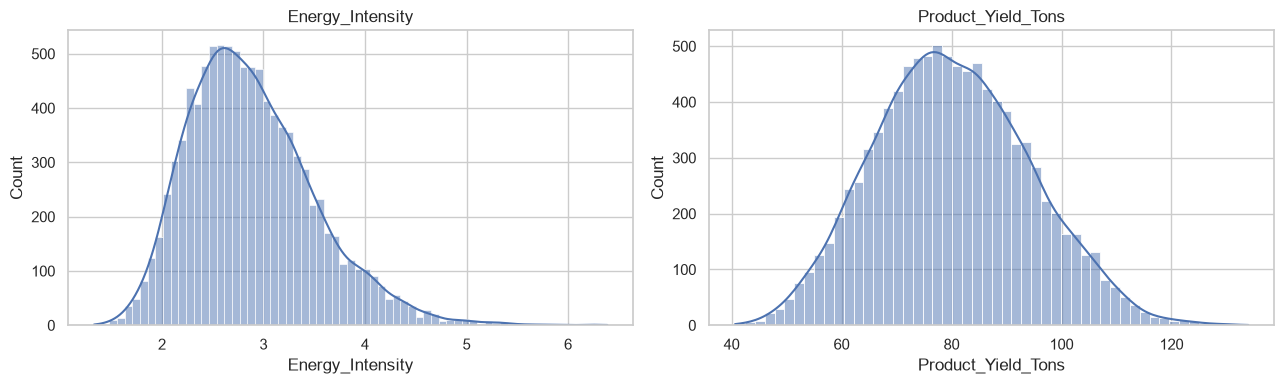

In [6]:
# 2.1 Distribuição dos targets
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, t in zip(ax, cfg.TARGETS):
    sns.histplot(df[t], kde=True, ax=a)
    a.set_title(t)
plt.tight_layout(); plt.show()


In [7]:
# Convenção para o resto da EDA (e do trabalho): como as 3 plantas fabricam
# produtos diferentes por processos diferentes, a análise abaixo é sempre
# feita SEPARADA POR PLANTA primeiro, e só depois comparada entre elas
# (ex.: um efeito sazonal que aparece nas 3 ao mesmo tempo, mesmo com
# níveis de produção/energia distintos, é um padrão comum que vale a pena
# investigar; um efeito que só aparece em uma planta é específico do processo).
PLANTAS = sorted(df["Unit_Name"].unique())
COR_PLANTA = dict(zip(PLANTAS, sns.color_palette("deep", len(PLANTAS))))
PLANTAS


['Ammonia_Unit_02', 'Ethylene_Plant_01', 'Methanol_Complex_03']

In [8]:
# 2.1.b De onde vêm os dois targets? Energy_Intensity é derivada?
# Antes de seguir a EDA, vale checar se os dois targets são duas medidas
# independentes ou se um é calculado a partir do outro (isso mudaria como
# interpretamos tudo daqui pra frente). Começa simples: correlação de
# Energy_Intensity com cada coluna de consumo bruto e com o outro target.
print("Correlação de Energy_Intensity com cada variável candidata:")
candidatos_ei = cfg.CONSUMO_ENERGIA + ["Product_Yield_Tons"]
for c in candidatos_ei:
    print(f"  {c:<20} corr = {df[c].corr(df['Energy_Intensity']):+.4f}")

print()
print("Será um PRODUTO simples de 2 colunas? Testando as combinações mais óbvias:")
print(f"  Electricity_MWh / Yield        corr = {(df['Electricity_MWh']/df['Product_Yield_Tons']).corr(df['Energy_Intensity']):.4f}")
print(f"  Natural_Gas_m3h / Yield        corr = {(df['Natural_Gas_m3h']/df['Product_Yield_Tons']).corr(df['Energy_Intensity']):.4f}")
print("  -> nenhuma bate perfeito sozinha. Ajustando uma combinação linear calibrada:")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Z = df[cfg.CONSUMO_ENERGIA].div(df["Product_Yield_Tons"], axis=0)
lin = LinearRegression().fit(Z, df["Energy_Intensity"])
pred = lin.predict(Z)
r2 = r2_score(df["Energy_Intensity"], pred)

print(f"\nEnergy_Intensity ~ {lin.coef_[0]:.4f}*(Electricity_MWh/Yield)"
      f" + {lin.coef_[1]:.4f}*(Natural_Gas_m3h/Yield)"
      f" + {lin.coef_[2]:.6f}*(Steam_Tons_h/Yield) + {lin.intercept_:.6f}")
print(f"R² = {r2:.6f}")
print()
print(">> R² praticamente 1.0: Energy_Intensity NÃO é uma medição independente.")
print(">> E também NÃO é um produto simples de 2 colunas — é uma razão calibrada,")
print(">> envolvendo 3 colunas (Electricity_MWh, Natural_Gas_m3h e o OUTRO target,")
print(">> Product_Yield_Tons, no denominador). Isso já muda como interpretamos os")
print(">> dois targets — ver seção 1.1 e as células seguintes (2.1.c a 2.1.f).")


Correlação de Energy_Intensity com cada variável candidata:
  Electricity_MWh      corr = +0.3260
  Natural_Gas_m3h      corr = +0.4052
  Steam_Tons_h         corr = +0.0083
  Product_Yield_Tons   corr = -0.8192

Será um PRODUTO simples de 2 colunas? Testando as combinações mais óbvias:
  Electricity_MWh / Yield        corr = 0.8183
  Natural_Gas_m3h / Yield        corr = 0.9265
  -> nenhuma bate perfeito sozinha. Ajustando uma combinação linear calibrada:

Energy_Intensity ~ 3.6000*(Electricity_MWh/Yield) + 0.0350*(Natural_Gas_m3h/Yield) + -0.000000*(Steam_Tons_h/Yield) + 0.000000
R² = 1.000000

>> R² praticamente 1.0: Energy_Intensity NÃO é uma medição independente.
>> E também NÃO é um produto simples de 2 colunas — é uma razão calibrada,
>> envolvendo 3 colunas (Electricity_MWh, Natural_Gas_m3h e o OUTRO target,
>> Product_Yield_Tons, no denominador). Isso já muda como interpretamos os
>> dois targets — ver seção 1.1 e as células seguintes (2.1.c a 2.1.f).


In [9]:
# 2.1.c Confirmando a fórmula com os coeficientes achados acima
# Reconstruindo Energy_Intensity com os coeficientes calibrados em 2.1.b:
df["Energia_por_Tonelada"] = (
    3.6 * df["Electricity_MWh"] + 0.035 * df["Natural_Gas_m3h"]
) / df["Product_Yield_Tons"]

diff = (df["Energia_por_Tonelada"] - df["Energy_Intensity"]).abs().max()
print(f"Diferença máxima vs. Energy_Intensity: {diff:.2e}")
print(">> Confirmado: é a MESMA coisa, com coeficientes redondos (3.6 e 0.035) —")
print(">> Energy_Intensity foi construída dessa forma na geração do dataset.")
print(">> Não faz sentido manter uma coluna duplicada — usamos Energy_Intensity")
print(">> diretamente pelo resto do notebook, sabendo exatamente o que ela significa.")

df = df.drop(columns=["Energia_por_Tonelada"])


Diferença máxima vs. Energy_Intensity: 1.78e-15
>> Confirmado: é a MESMA coisa, com coeficientes redondos (3.6 e 0.035) —
>> Energy_Intensity foi construída dessa forma na geração do dataset.
>> Não faz sentido manter uma coluna duplicada — usamos Energy_Intensity
>> diretamente pelo resto do notebook, sabendo exatamente o que ela significa.


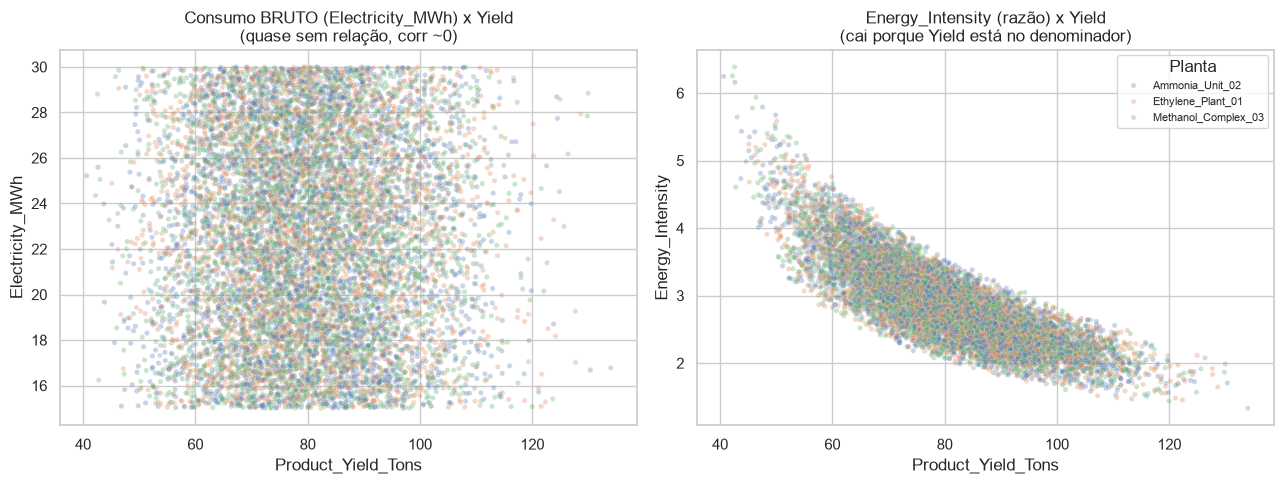

In [10]:
# 2.1.d Consumo bruto x Yield: contraste visual
# Confirmação visual do que já foi mostrado em 2.1.b: o consumo BRUTO de
# energia é achatado contra a produção, enquanto Energy_Intensity (a razão)
# cai — porque Yield está no denominador dela, não porque gastar menos
# energia produz mais.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="Product_Yield_Tons", y="Electricity_MWh",
                 hue="Unit_Name", hue_order=PLANTAS, palette=COR_PLANTA,
                 alpha=0.3, s=14, ax=axes[0], legend=False)
axes[0].set_title("Consumo BRUTO (Electricity_MWh) x Yield\n(quase sem relação, corr ~0)")

sns.scatterplot(data=df, x="Product_Yield_Tons", y="Energy_Intensity",
                 hue="Unit_Name", hue_order=PLANTAS, palette=COR_PLANTA,
                 alpha=0.3, s=14, ax=axes[1])
axes[1].set_title("Energy_Intensity (razão) x Yield\n(cai porque Yield está no denominador)")
axes[1].legend(title="Planta", fontsize=8)
plt.tight_layout(); plt.show()


In [11]:
# 2.1.e O que explica o consumo BRUTO de energia? (spoiler: nada)
# As seções 2.1.b-d mostraram que Energy_Intensity é só uma razão (energia/Yield).
# Falta testar a pergunta que realmente importa: o consumo BRUTO de energia
# (Electricity_MWh, Natural_Gas_m3h, Steam_Tons_h) responde a ALGUMA variável
# operacional (controlável, de estado, externa, ou até a planta)? Se sim, essa
# é a alavanca real para classificar configurações por consumo energético.
candidatos = cfg.CONTROLAVEIS + cfg.ESTADO + ["Ambient_Temp_C"]
linhas = []
for e in cfg.CONSUMO_ENERGIA:
    linha = {"Variavel_energia": e}
    for c in candidatos:
        linha[c] = df[e].corr(df[c])
    linhas.append(linha)
tabela_corr_energia_bruta = pd.DataFrame(linhas).set_index("Variavel_energia")
display(tabela_corr_energia_bruta.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

print("Média de cada consumo por planta (a planta muda o patamar de consumo?):")
display(df.groupby("Unit_Name")[cfg.CONSUMO_ENERGIA].mean().loc[PLANTAS])

print()
print(">> TODAS as correlações estão abaixo de 0.09 em módulo, e as médias por planta")
print(">> são quase idênticas. O consumo bruto de energia não responde a NENHUMA variável")
print(">> operacional medida — é ruído estatístico (provavelmente sorteado de forma")
print(">> independente na geração sintética dos dados), não uma função da configuração.")


,Feedstock_Flow_m3h,Reactor_Temp_C,Reactor_Pressure_Bar,Valve_Opening_Percent,Catalyst_Age_Days,Sensor_Health_Index,Vibration_Level_mm_s,Ambient_Temp_C
Variavel_energia,,,,,,,,
Electricity_MWh,-0.001587,0.005231,0.003722,-0.007282,0.007117,-0.006654,-0.010433,0.012471
Natural_Gas_m3h,0.021675,0.017389,0.024929,-0.006899,0.086538,0.006928,-0.010888,-0.001904
Steam_Tons_h,-0.015722,0.007020,0.011665,-0.007875,-0.004826,-0.009353,0.017266,-0.019749


Média de cada consumo por planta (a planta muda o patamar de consumo?):


,Electricity_MWh,Natural_Gas_m3h,Steam_Tons_h
Unit_Name,,,
Ammonia_Unit_02,22.4430,"4,097.4980",65.1356
Ethylene_Plant_01,22.6157,"4,089.9874",64.6219
Methanol_Complex_03,22.4404,"4,089.2148",65.1778



>> TODAS as correlações estão abaixo de 0.09 em módulo, e as médias por planta
>> são quase idênticas. O consumo bruto de energia não responde a NENHUMA variável
>> operacional medida — é ruído estatístico (provavelmente sorteado de forma
>> independente na geração sintética dos dados), não uma função da configuração.


R² de Energy_Intensity usando SÓ a média fixa de energia / Yield real: 0.7110
(compare com o R² dos modelos de ML da seção 5, que usam TODAS as features reais:
 Ridge ~0.68, GradientBoosting ~0.68 — veja tabela_modelos)


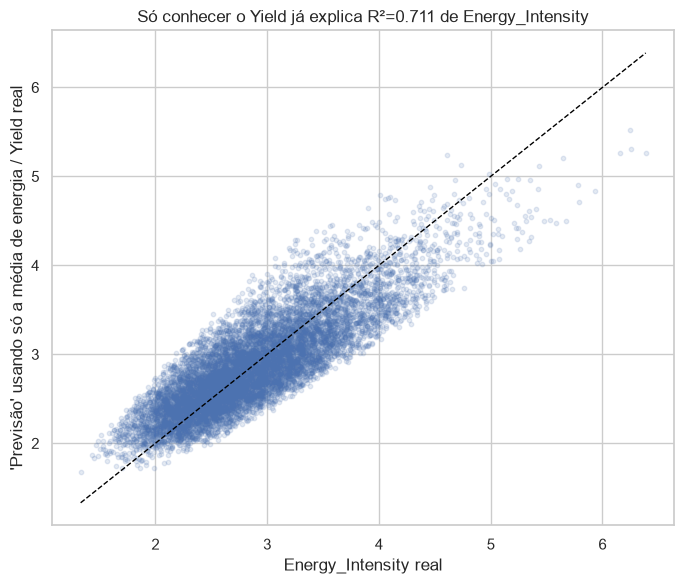


>> Esse R², obtido SEM usar nenhuma feature real (só a média fixa de energia),
>> é próximo — e às vezes maior — do que os modelos de ML da seção 5 conseguem
>> com todas as features. Ou seja: o modelo de Energy_Intensity não está aprendendo
>> uma relação real de eficiência energética — ele está, na prática, só aprendendo
>> a prever o Yield e dividir. Os dois targets NÃO são duas perguntas de negócio
>> independentes neste dataset: Energy_Intensity é algebricamente refém de Yield,
>> e o numerador (energia bruta) é ruído que nenhuma configuração operacional muda.
>> Implicação prática: 'a melhor configuração para consumo energético' não existe
>> como pergunta respondível neste dataset — a única alavanca real é maximizar
>> Product_Yield_Tons (via Feedstock_Flow e Sensor_Health_Index), o que dilui um
>> custo energético que é, na prática, fixo e aleatório. Vale registrar isso
>> explicitamente no relatório, como extensão do achado da seção 4.1.b.


In [12]:
# 2.1.f Quanto da capacidade preditiva de Energy_Intensity é só "conhecer o Yield"?
# Se o consumo bruto de energia é ruído (2.1.e), então Energy_Intensity = ruído/Yield.
# Teste: em vez do consumo REAL, usa a MÉDIA FIXA de Electricity/Gas (finge que a
# energia não varia nada) dividida pelo Yield REAL, e compara com Energy_Intensity real.
elec_mean = df["Electricity_MWh"].mean()
gas_mean = df["Natural_Gas_m3h"].mean()
ei_so_com_yield = (3.6 * elec_mean + 0.035 * gas_mean) / df["Product_Yield_Tons"]
r2_so_com_yield = r2_score(df["Energy_Intensity"], ei_so_com_yield)

print(f"R² de Energy_Intensity usando SÓ a média fixa de energia / Yield real: {r2_so_com_yield:.4f}")
print("(compare com o R² dos modelos de ML da seção 5, que usam TODAS as features reais:")
print(" Ridge ~0.68, GradientBoosting ~0.68 — veja tabela_modelos)")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["Energy_Intensity"], ei_so_com_yield, alpha=0.15, s=10)
lims = [df["Energy_Intensity"].min(), df["Energy_Intensity"].max()]
ax.plot(lims, lims, color="black", lw=1, ls="--")
ax.set_xlabel("Energy_Intensity real")
ax.set_ylabel("'Previsão' usando só a média de energia / Yield real")
ax.set_title(f"Só conhecer o Yield já explica R²={r2_so_com_yield:.3f} de Energy_Intensity")
plt.tight_layout(); plt.show()

print()
print(">> Esse R², obtido SEM usar nenhuma feature real (só a média fixa de energia),")
print(">> é próximo — e às vezes maior — do que os modelos de ML da seção 5 conseguem")
print(">> com todas as features. Ou seja: o modelo de Energy_Intensity não está aprendendo")
print(">> uma relação real de eficiência energética — ele está, na prática, só aprendendo")
print(">> a prever o Yield e dividir. Os dois targets NÃO são duas perguntas de negócio")
print(">> independentes neste dataset: Energy_Intensity é algebricamente refém de Yield,")
print(">> e o numerador (energia bruta) é ruído que nenhuma configuração operacional muda.")
print(">> Implicação prática: 'a melhor configuração para consumo energético' não existe")
print(">> como pergunta respondível neste dataset — a única alavanca real é maximizar")
print(">> Product_Yield_Tons (via Feedstock_Flow e Sensor_Health_Index), o que dilui um")
print(">> custo energético que é, na prática, fixo e aleatório. Vale registrar isso")
print(">> explicitamente no relatório, como extensão do achado da seção 4.1.b.")


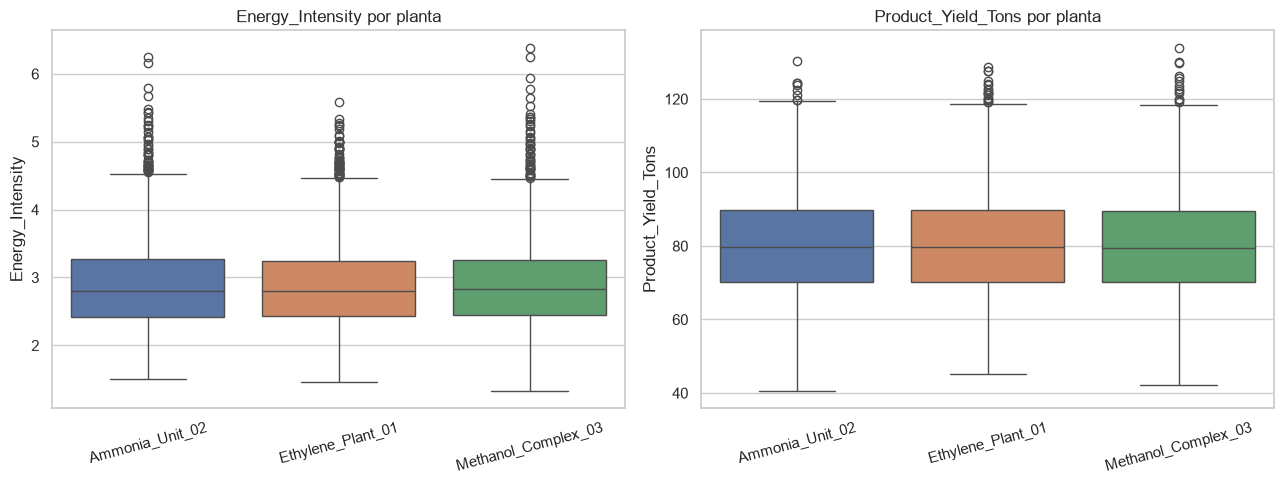

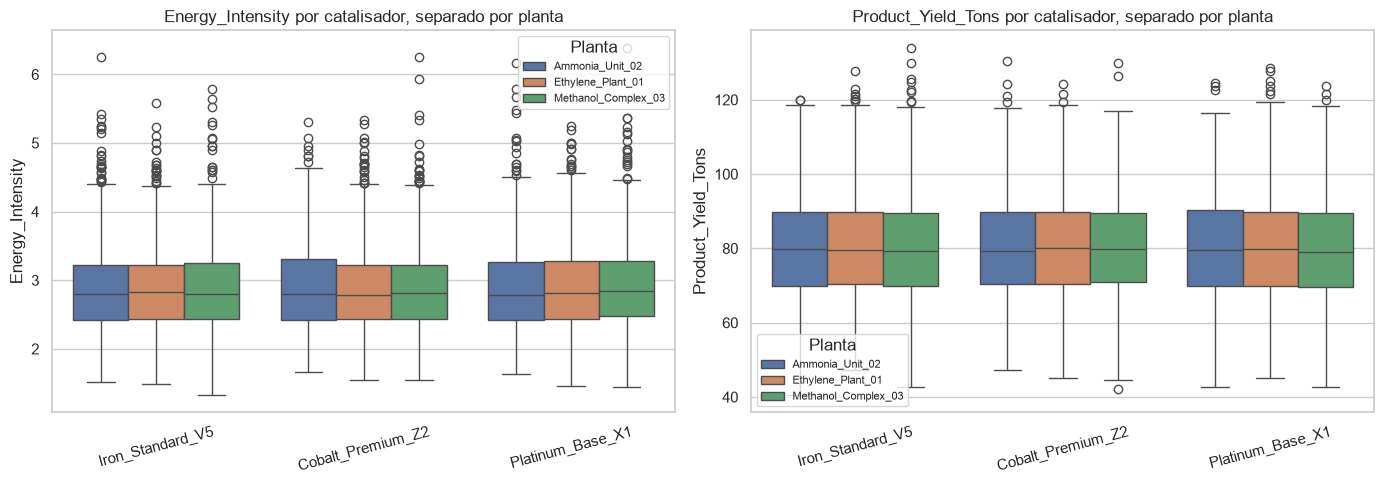

Médias por planta:


,Energy_Intensity,Product_Yield_Tons
Unit_Name,,
Ammonia_Unit_02,2.8862,80.2622
Ethylene_Plant_01,2.8823,80.3822
Methanol_Complex_03,2.8870,80.0050



Médias por planta e catalisador (o efeito do catalisador muda por planta?):


Energy_Intensity  Product_Yield_Tons
Unit_Name           Catalyst_Type                                          
Ammonia_Unit_02     Cobalt_Premium_Z2            2.8966             80.1340
                    Iron_Standard_V5             2.8755             80.3280
                    Platinum_Base_X1             2.8863             80.3240
Ethylene_Plant_01   Cobalt_Premium_Z2            2.8724             80.3934
                    Iron_Standard_V5             2.8774             80.5055
                    Platinum_Base_X1             2.8970             80.2486
Methanol_Complex_03 Cobalt_Premium_Z2            2.8794             80.2904
                    Iron_Standard_V5             2.8724             79.9827
                    Platinum_Base_X1             2.9089             79.7472

In [13]:
# 2.2 Comportamento por unidade e por catalisador
# Pergunta: Unit_Name e Catalyst_Type definem populações estatisticamente
# diferentes? Se sim, o modelo precisa dessa informação (categórica) ou a
# otimização deve ser feita planta a planta.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, target in zip(axes, cfg.TARGETS):
    sns.boxplot(data=df, x="Unit_Name", y=target, order=PLANTAS,
                palette=COR_PLANTA, ax=ax)
    ax.set_title(f"{target} por planta")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, cfg.TARGETS):
    sns.boxplot(data=df, x="Catalyst_Type", y=target, hue="Unit_Name",
                hue_order=PLANTAS, palette=COR_PLANTA, ax=ax)
    ax.set_title(f"{target} por catalisador, separado por planta")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Planta", fontsize=8)
plt.tight_layout(); plt.show()

print("Médias por planta:")
display(df.groupby("Unit_Name")[cfg.TARGETS].mean().loc[PLANTAS])

print("\nMédias por planta e catalisador (o efeito do catalisador muda por planta?):")
display(df.groupby(["Unit_Name", "Catalyst_Type"])[cfg.TARGETS].mean())


,Media,Desvio,N
Catalyst_Type,,,
Iron_Standard_V5,2.8751,0.6225,3297
Cobalt_Premium_Z2,2.8828,0.6220,3333
Platinum_Base_X1,2.8973,0.6310,3370


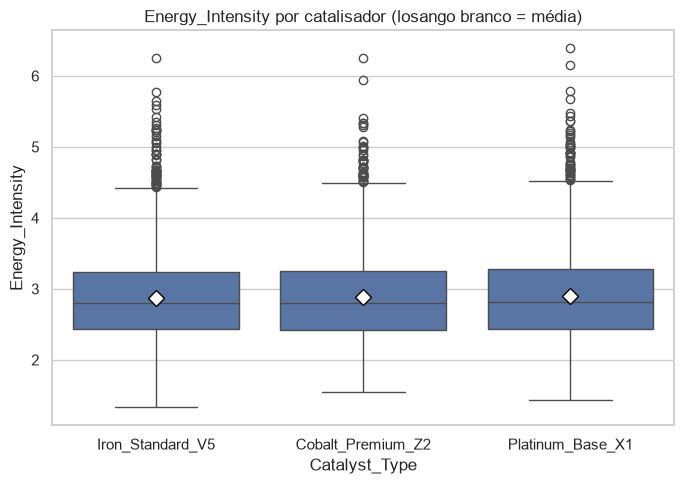

Diferença entre a maior e a menor média: 0.77% — dentro de 1 desvio-padrão.
>> As médias por catalisador são quase idênticas e os desvios-padrão se sobrepõem
>> quase totalmente: neste dataset, o catalisador NÃO parece ter efeito mensurável
>> sobre Energy_Intensity. É por isso que o boxplot 'não é produtivo' — não é falta
>> de um gráfico melhor, é que o efeito (se existir) é pequeno demais pra aparecer.


In [14]:
# 2.2.b Energy_Intensity por catalisador — tabela + boxplot com médias marcadas
# (o boxplot puro de 2.2 é pouco conclusivo porque as distribuições quase
# se sobrepõem; olhar a tabela ao lado do gráfico ajuda a confirmar isso)
resumo_catalisador = (
    df.groupby("Catalyst_Type")["Energy_Intensity"]
    .agg(Media="mean", Desvio="std", N="count")
    .sort_values("Media")
)
display(resumo_catalisador)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Catalyst_Type", y="Energy_Intensity", order=resumo_catalisador.index,
            showmeans=True, meanprops={"marker": "D", "markerfacecolor": "white",
                                        "markeredgecolor": "black", "markersize": 8}, ax=ax)
ax.set_title("Energy_Intensity por catalisador (losango branco = média)")
plt.tight_layout(); plt.show()

diferenca_pct = (resumo_catalisador["Media"].max() / resumo_catalisador["Media"].min() - 1) * 100
print(f"Diferença entre a maior e a menor média: {diferenca_pct:.2f}% — dentro de 1 desvio-padrão.")
print(">> As médias por catalisador são quase idênticas e os desvios-padrão se sobrepõem")
print(">> quase totalmente: neste dataset, o catalisador NÃO parece ter efeito mensurável")
print(">> sobre Energy_Intensity. É por isso que o boxplot 'não é produtivo' — não é falta")
print(">> de um gráfico melhor, é que o efeito (se existir) é pequeno demais pra aparecer.")


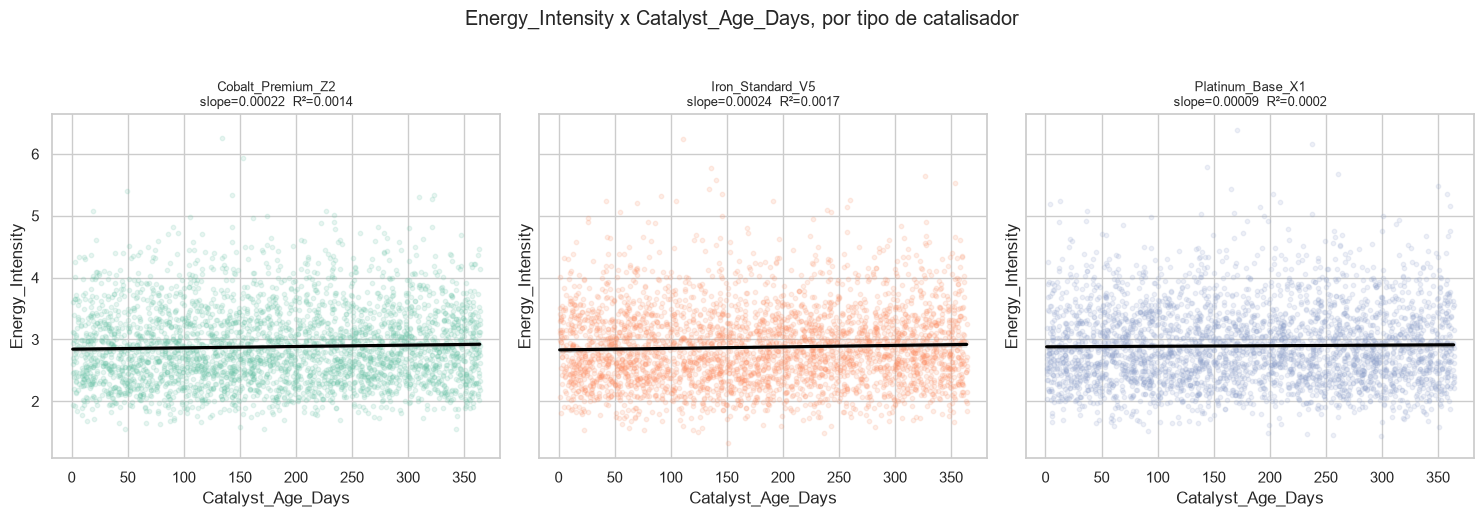

,slope,intercept,r2
Cobalt_Premium_Z2,0.0002,2.8428,0.0014
Iron_Standard_V5,0.0002,2.8314,0.0017
Platinum_Base_X1,0.0001,2.8812,0.0002


>> Slopes muito próximos de 0 e R² < 0,002 nos três catalisadores: Energy_Intensity
>> praticamente não varia com a idade do catalisador, em nenhum dos três tipos.
>> Combinado com 1.2 (Catalyst_Age_Days 'reseta' de forma pouco realista entre leituras)
>> e com 2.3 (mesmo resultado quase-zero por planta), a conclusão é consistente:
>> neste dataset sintético, a idade do catalisador não é um preditor real de eficiência —
>> Vibration_Level_mm_s (seção 2.3) continua sendo o sinal de degradação mais confiável.


In [15]:
# 2.2.c Energy_Intensity ao longo da idade do catalisador, por tipo de catalisador
# Pergunta original: será que Energy_Intensity varia com Catalyst_Age_Days de
# forma diferente para cada catalisador (um catalisador que degrada mais rápido)?
from sklearn.metrics import r2_score

CATALISADORES = sorted(df["Catalyst_Type"].unique())
COR_CATALISADOR = dict(zip(CATALISADORES, sns.color_palette("Set2", len(CATALISADORES))))
COEF_CATALISADOR = {}

fig, axes = plt.subplots(1, len(CATALISADORES), figsize=(15, 5), sharey=True)
for ax, cat in zip(axes, CATALISADORES):
    sub = df[df["Catalyst_Type"] == cat]
    sns.regplot(
        data=sub, x="Catalyst_Age_Days", y="Energy_Intensity", ax=ax,
        scatter_kws={"alpha": 0.15, "s": 10, "color": COR_CATALISADOR[cat]},
        line_kws={"color": "black"},
    )
    slope, intercept = np.polyfit(sub["Catalyst_Age_Days"], sub["Energy_Intensity"], 1)
    r2 = r2_score(sub["Energy_Intensity"], slope * sub["Catalyst_Age_Days"] + intercept)
    COEF_CATALISADOR[cat] = {"slope": slope, "intercept": intercept, "r2": r2}
    ax.set_title(f"{cat}\nslope={slope:.5f}  R²={r2:.4f}", fontsize=9)
plt.suptitle("Energy_Intensity x Catalyst_Age_Days, por tipo de catalisador", y=1.03)
plt.tight_layout(); plt.show()

tabela_catalisador = pd.DataFrame(COEF_CATALISADOR).T
display(tabela_catalisador)

print(">> Slopes muito próximos de 0 e R² < 0,002 nos três catalisadores: Energy_Intensity")
print(">> praticamente não varia com a idade do catalisador, em nenhum dos três tipos.")
print(">> Combinado com 1.2 (Catalyst_Age_Days 'reseta' de forma pouco realista entre leituras)")
print(">> e com 2.3 (mesmo resultado quase-zero por planta), a conclusão é consistente:")
print(">> neste dataset sintético, a idade do catalisador não é um preditor real de eficiência —")
print(">> Vibration_Level_mm_s (seção 2.3) continua sendo o sinal de degradação mais confiável.")


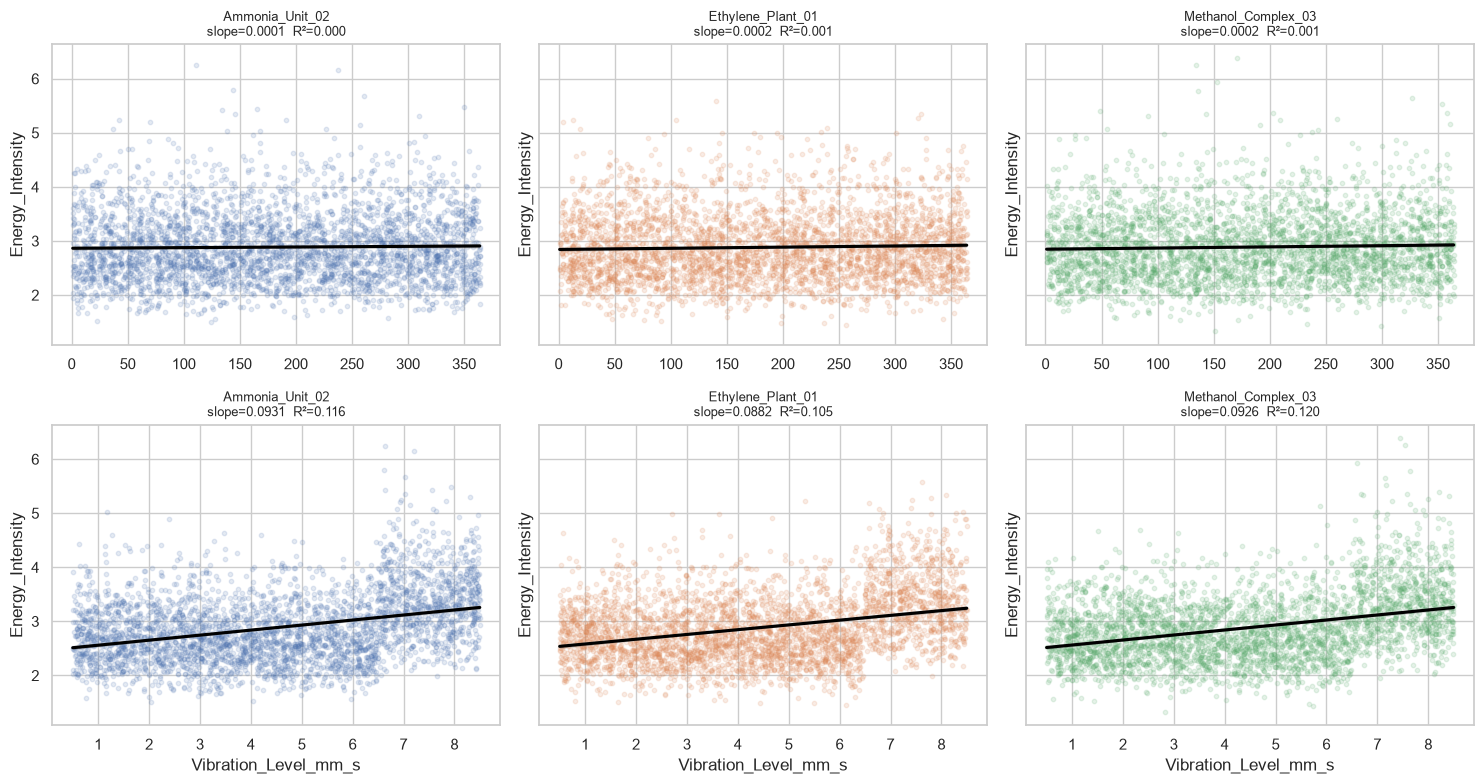

,,slope,intercept,r2
Planta,Variavel,,,
Ammonia_Unit_02,Catalyst_Age_Days,0.0001,2.8652,0.0004
Ethylene_Plant_01,Catalyst_Age_Days,0.0002,2.8431,0.0014
Methanol_Complex_03,Catalyst_Age_Days,0.0002,2.8479,0.0013
Ammonia_Unit_02,Vibration_Level_mm_s,0.0931,2.4660,0.1155
Ethylene_Plant_01,Vibration_Level_mm_s,0.0882,2.4935,0.1055
Methanol_Complex_03,Vibration_Level_mm_s,0.0926,2.4701,0.1200


In [16]:
# 2.3 Degradação: a evidência que sustenta a decisão de manutenção
# Para cada planta, ajusta uma tendência linear simples de Catalyst_Age_Days
# e de Vibration_Level_mm_s contra Energy_Intensity. Os coeficientes (slope)
# ficam guardados em COEF_DEGRADACAO — é o "quanto a eficiência piora por
# dia/por mm/s" que a seção 7 usa para projetar o estado do equipamento no tempo.
from sklearn.metrics import r2_score

VARS_DEGRADACAO = ["Catalyst_Age_Days", "Vibration_Level_mm_s"]
COEF_DEGRADACAO = {}

fig, axes = plt.subplots(len(VARS_DEGRADACAO), len(PLANTAS), figsize=(15, 8), sharey="row")
for i, var in enumerate(VARS_DEGRADACAO):
    for j, planta in enumerate(PLANTAS):
        ax = axes[i, j]
        sub = df[df["Unit_Name"] == planta]
        sns.regplot(
            data=sub, x=var, y="Energy_Intensity", ax=ax,
            scatter_kws={"alpha": 0.15, "s": 10, "color": COR_PLANTA[planta]},
            line_kws={"color": "black"},
        )
        slope, intercept = np.polyfit(sub[var], sub["Energy_Intensity"], 1)
        r2 = r2_score(sub["Energy_Intensity"], slope * sub[var] + intercept)
        COEF_DEGRADACAO[(planta, var)] = {"slope": slope, "intercept": intercept, "r2": r2}
        ax.set_title(f"{planta}\nslope={slope:.4f}  R²={r2:.3f}", fontsize=9)
        if i == 0:
            ax.set_xlabel("")
plt.tight_layout(); plt.show()

tabela_degradacao = pd.DataFrame(COEF_DEGRADACAO).T
tabela_degradacao.index.names = ["Planta", "Variavel"]
tabela_degradacao


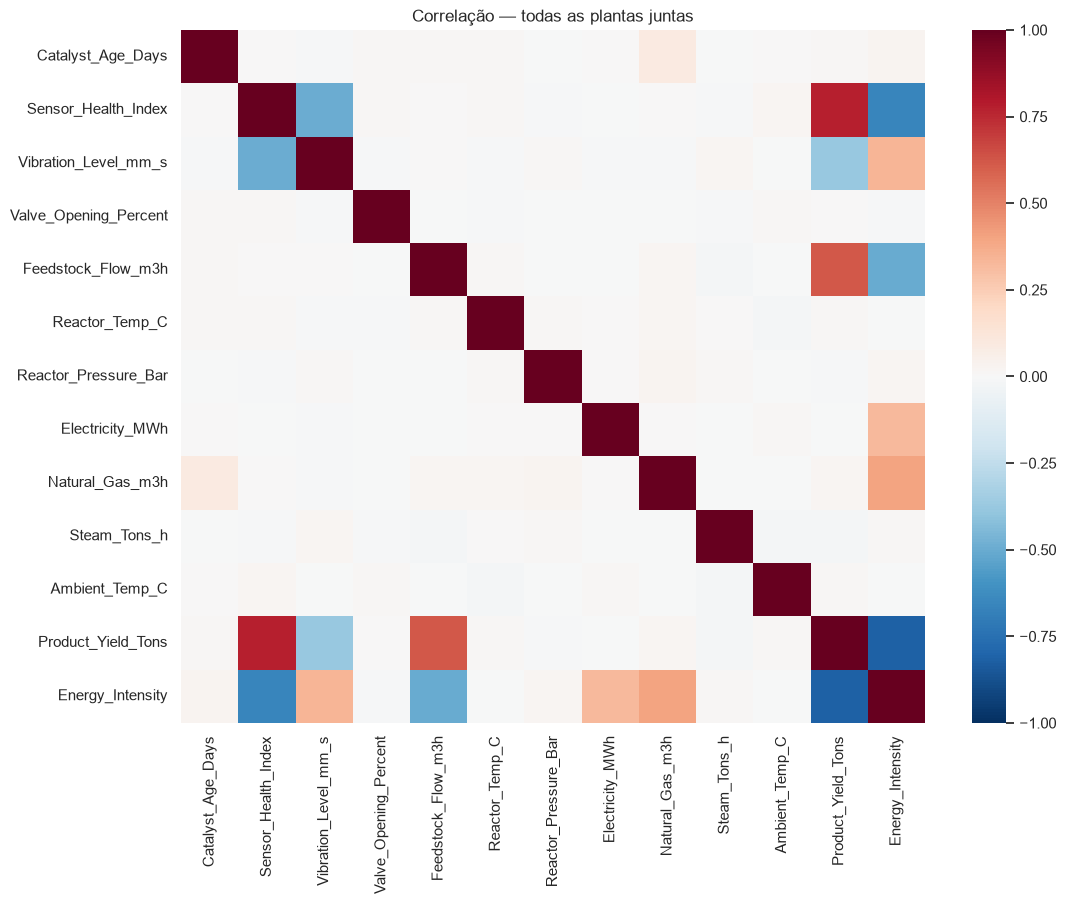

,Energy_Intensity,Product_Yield_Tons
Energy_Intensity,1.0000,-0.8192
Natural_Gas_m3h,0.4052,0.0194
Vibration_Level_mm_s,0.3371,-0.3813
Electricity_MWh,0.3260,-0.0063
Catalyst_Age_Days,0.0308,0.0081
Reactor_Pressure_Bar,0.0198,-0.0084
Steam_Tons_h,0.0083,-0.0169
Reactor_Temp_C,-0.0025,0.0140
Ambient_Temp_C,-0.0064,0.0133
Valve_Opening_Percent,-0.0080,0.0044


In [17]:
# 2.4 Correlação — global e por planta
# Pergunta: a estrutura de correlação (o que se relaciona com o quê) é a
# mesma nas 3 plantas, ou cada produto/processo tem sua própria "assinatura"?
# Visão global primeiro, como baseline de comparação.
num = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 9))
sns.heatmap(num.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=False)
plt.title("Correlação — todas as plantas juntas")
plt.show()

num.corr()[cfg.TARGETS].sort_values("Energy_Intensity", ascending=False)


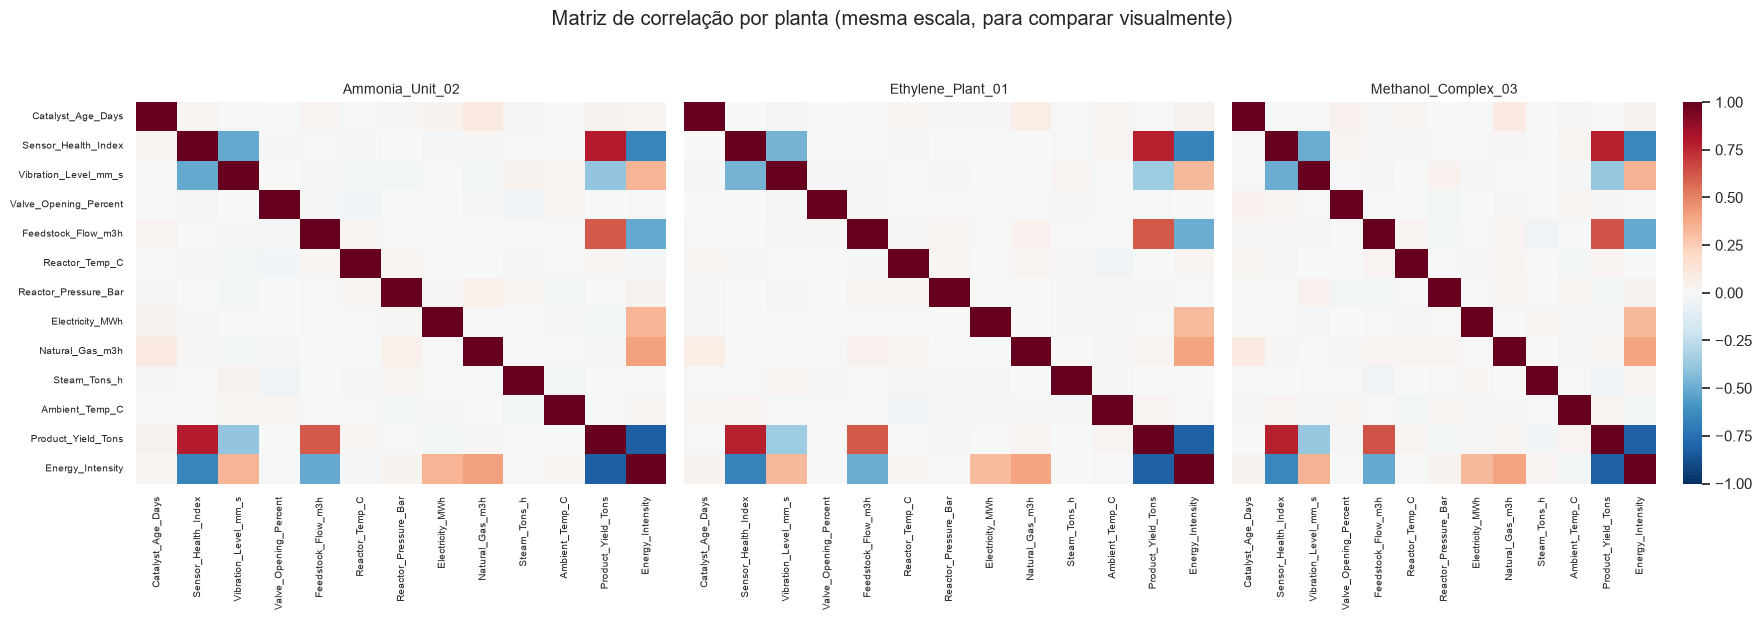

In [18]:
# 2.4.b Matriz de correlação por planta, na mesma escala (-1 a 1) para comparar
corr_por_planta = df.groupby("Unit_Name")[list(num.columns)].corr()

fig, axes = plt.subplots(1, len(PLANTAS), figsize=(18, 6), sharey=True)
for ax, planta in zip(axes, PLANTAS):
    sns.heatmap(corr_por_planta.loc[planta], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                cbar=(planta == PLANTAS[-1]), ax=ax, annot=False)
    ax.set_title(planta, fontsize=10)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
plt.suptitle("Matriz de correlação por planta (mesma escala, para comparar visualmente)", y=1.03)
plt.tight_layout(); plt.show()


In [19]:
# 2.4.c Correlação de cada variável com os dois targets, lado a lado por planta
corr_targets_planta = pd.concat(
    {planta: corr_por_planta.loc[planta, cfg.TARGETS] for planta in PLANTAS}, axis=1
).drop(index=cfg.TARGETS)  # remove target x target (sempre 1.0 / a correlação entre os targets)
corr_targets_planta


Ammonia_Unit_02                    Ethylene_Plant_01  \
                      Energy_Intensity Product_Yield_Tons  Energy_Intensity   
Catalyst_Age_Days               0.0192             0.0374            0.0371   
Sensor_Health_Index            -0.6592             0.7833           -0.6643   
Vibration_Level_mm_s            0.3399            -0.3919            0.3248   
Valve_Opening_Percent          -0.0112            -0.0015           -0.0078   
Feedstock_Flow_m3h             -0.5125             0.6165           -0.4939   
Reactor_Temp_C                 -0.0166             0.0182            0.0158   
Reactor_Pressure_Bar            0.0319            -0.0100           -0.0093   
Electricity_MWh                 0.3366            -0.0279            0.3201   
Natural_Gas_m3h                 0.4076             0.0099            0.4050   
Steam_Tons_h                    0.0039            -0.0139           -0.0051   
Ambient_Temp_C                  0.0206            -0.0116           -0.0112   

                                         Methanol_Complex_03  \
                      Product_Yield_Tons    Energy_Intensity   
Catalyst_Age_Days                -0.0111              0.0365   
Sensor_Health_Index               0.7788             -0.6509   
Vibration_Level_mm_s             -0.3619              0.3464   
Valve_Opening_Percent             0.0032             -0.0051   
Feedstock_Flow_m3h                0.6243             -0.5140   
Reactor_Temp_C                   -0.0025             -0.0065   
Reactor_Pressure_Bar              0.0101              0.0379   
Electricity_MWh                   0.0006              0.3214   
Natural_Gas_m3h                   0.0263              0.4031   
Steam_Tons_h                     -0.0042              0.0264   
Ambient_Temp_C                    0.0260             -0.0299   

                                          
                      Product_Yield_Tons  
Catalyst_Age_Days                -0.0022  
Sensor_Health_Index               0.7744  
Vibration_Level_mm_s             -0.3899  
Valve_Opening_Percent             0.0122  
Feedstock_Flow_m3h                0.6340  
Reactor_Temp_C                    0.0274  
Reactor_Pressure_Bar             -0.0271  
Electricity_MWh                   0.0084  
Natural_Gas_m3h                   0.0219  
Steam_Tons_h                     -0.0325  
Ambient_Temp_C                    0.0255

In [20]:
# 2.4.d Onde as plantas mais divergem? (maior variação de correlação com o
# target entre elas — é aqui que uma "assinatura" específica de processo apareceria)
linhas = []
for target in cfg.TARGETS:
    sub = corr_targets_planta.xs(target, axis=1, level=1)
    for var in sub.index:
        linhas.append({
            "Target": target,
            "Variavel": var,
            **{p: sub.loc[var, p] for p in PLANTAS},
            "Diferenca_max_min": sub.loc[var].max() - sub.loc[var].min(),
        })
tabela_divergencia = pd.DataFrame(linhas).sort_values("Diferenca_max_min", ascending=False)
tabela_divergencia.head(10)


,Target,Variavel,Ammonia_Unit_02,Ethylene_Plant_01,Methanol_Complex_03,Diferenca_max_min
10,Energy_Intensity,Ambient_Temp_C,0.0206,-0.0112,-0.0299,0.0505
11,Product_Yield_Tons,Catalyst_Age_Days,0.0374,-0.0111,-0.0022,0.0485
6,Energy_Intensity,Reactor_Pressure_Bar,0.0319,-0.0093,0.0379,0.0472
21,Product_Yield_Tons,Ambient_Temp_C,-0.0116,0.0260,0.0255,0.0376
17,Product_Yield_Tons,Reactor_Pressure_Bar,-0.0100,0.0101,-0.0271,0.0372
18,Product_Yield_Tons,Electricity_MWh,-0.0279,0.0006,0.0084,0.0363
5,Energy_Intensity,Reactor_Temp_C,-0.0166,0.0158,-0.0065,0.0324
9,Energy_Intensity,Steam_Tons_h,0.0039,-0.0051,0.0264,0.0315
13,Product_Yield_Tons,Vibration_Level_mm_s,-0.3919,-0.3619,-0.3899,0.0300
16,Product_Yield_Tons,Reactor_Temp_C,0.0182,-0.0025,0.0274,0.0299


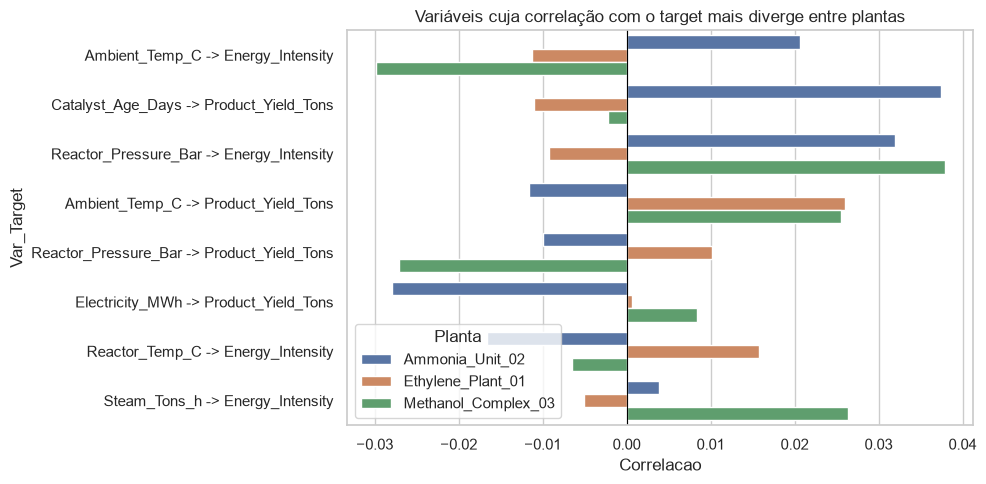

In [21]:
# 2.4.e As maiores divergências, visualmente
top = tabela_divergencia.head(8).copy()
top["Var_Target"] = top["Variavel"] + " -> " + top["Target"]
plot_df = top.melt(id_vars="Var_Target", value_vars=PLANTAS, var_name="Planta", value_name="Correlacao")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Correlacao", y="Var_Target", hue="Planta",
            hue_order=PLANTAS, palette=COR_PLANTA)
plt.axvline(0, color="black", lw=0.8)
plt.title("Variáveis cuja correlação com o target mais diverge entre plantas")
plt.tight_layout(); plt.show()


## 3. Feature engineering

Ideias que costumam pagar bem neste dataset (escolher, testar, e **justificar no relatório**):

- **Severidade do processo:** `Reactor_Temp_C * Reactor_Pressure_Bar`, ou temperatura normalizada pela faixa da unidade.
- **Carga relativa:** `Feedstock_Flow_m3h / Valve_Opening_Percent` (vazão por abertura ≈ restrição hidráulica).
- **Delta térmico:** `Reactor_Temp_C - Ambient_Temp_C` — captura a perda para o ambiente, e é o canal pelo qual `Ambient_Temp_C` afeta a energia.
- **Degradação:** `Catalyst_Age_Days` normalizada pela vida útil, e um índice composto de saúde (vibração × idade × sensor health).
- **Temporais:** hora do dia, mês (sazonalidade de ambiente/energia). Cuidado para não criar features que não existiriam no momento da decisão.
- **Categóricas:** one-hot de `Unit_Name` e `Catalyst_Type`.

> **Regra de ouro deste trabalho:** toda feature que entra no modelo precisa ser (a) uma variável de decisão, (b) estado conhecido no momento da decisão, ou (c) externa previsível. Se não for nenhuma das três, ela não pode estar no modelo que alimenta o otimizador.


In [21]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    X = df.copy()
    X["Delta_Temp"] = X["Reactor_Temp_C"] - X["Ambient_Temp_C"]
    X["Severidade"] = X["Reactor_Temp_C"] * X["Reactor_Pressure_Bar"]
    X["Carga_por_Abertura"] = X["Feedstock_Flow_m3h"] / X["Valve_Opening_Percent"].replace(0, np.nan)
    X["Idade_Norm"] = X["Catalyst_Age_Days"] / cfg.LIMITE_IDADE_CATALISADOR
    # TODO: índice de degradação composto; features temporais; one-hot das categóricas
    return X

df_fe = build_features(df)
df_fe.head()


,Timestamp,Unit_Name,Catalyst_Type,Catalyst_Age_Days,Sensor_Health_Index,Vibration_Level_mm_s,Valve_Opening_Percent,Feedstock_Flow_m3h,Reactor_Temp_C,Reactor_Pressure_Bar,Electricity_MWh,Natural_Gas_m3h,Steam_Tons_h,Ambient_Temp_C,Product_Yield_Tons,Energy_Intensity,Delta_Temp,Severidade,Carga_por_Abertura,Idade_Norm
0,2020-01-01 00:00:00,Methanol_Complex_03,Iron_Standard_V5,228,0.9371,3.5710,42.2678,640.2060,822.7945,30.6686,17.2057,"4,161.0730",53.0997,-9.2433,107.9938,1.9221,832.0378,"25,233.9312",15.1464,0.5700
1,2020-01-01 04:00:00,Ethylene_Plant_01,Cobalt_Premium_Z2,298,0.7410,1.4459,40.5605,589.3432,788.9340,29.6742,20.0761,"4,896.9311",53.1076,16.6929,78.6073,3.0998,772.2411,"23,411.0006",14.5300,0.7450
2,2020-01-01 08:00:00,Methanol_Complex_03,Cobalt_Premium_Z2,291,0.8086,5.0400,70.7702,560.4219,777.9860,30.4054,15.5592,"3,553.3127",59.7059,6.3103,81.5676,2.2114,771.6757,"23,654.9752",7.9189,0.7275
3,2020-01-01 12:00:00,Methanol_Complex_03,Platinum_Base_X1,67,0.6713,8.1189,89.6138,666.9878,764.7108,33.0564,17.5461,"4,985.7114",72.9536,0.5864,80.6001,2.9487,764.1245,"25,278.6194",7.4429,0.1675
4,2020-01-01 16:00:00,Ethylene_Plant_01,Cobalt_Premium_Z2,251,0.8272,4.8401,39.0654,634.5843,769.0897,27.5199,23.3172,"3,505.9653",86.3124,23.1502,94.4818,2.1872,745.9394,"21,165.2561",16.2442,0.6275


## 4. Target leakage — a seção que vale nota

O enunciado avisa explicitamente: *"verificar possível target leakage, especialmente nas variáveis de energia"*.

`Electricity_MWh`, `Natural_Gas_m3h` e `Steam_Tons_h` são **medições do consumo que já aconteceu**. `Energy_Intensity` é, muito provavelmente, energia total ÷ produção. Se você usar essas colunas como feature:

- o R² fica perto de 1 e parece ótimo;
- o modelo é **inútil para otimizar**, porque para prever a energia de uma configuração nova você precisaria já saber quanta energia ela consumiu.

*(A identidade foi adiantada na seção 2.1.b-c, como curiosidade sobre a relação entre os targets; aqui o tratamento é formal e focado na decisão de quais colunas excluir do pipeline de ML.)*

A célula abaixo **testa** a hipótese em vez de só afirmá-la. Reproduza a relação aritmética; se o ajuste for quase perfeito, você tem a prova documental do leakage para colocar no relatório.


In [22]:
# 4.1 Reconstruir Energy_Intensity a partir dos consumos medidos
# Hipótese: Energy_Intensity ≈ (a*Electricity + b*Gas + c*Steam) / Product_Yield_Tons
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Z = df[cfg.CONSUMO_ENERGIA].div(df["Product_Yield_Tons"], axis=0)
lin = LinearRegression().fit(Z, df["Energy_Intensity"])
pred = lin.predict(Z)

print("Coeficientes:", dict(zip(cfg.CONSUMO_ENERGIA, lin.coef_.round(6))))
print("Intercepto   :", round(lin.intercept_, 6))
print("R²           :", round(r2_score(df["Energy_Intensity"], pred), 6))
print("\n>> R² ~1.0 confirma que Energy_Intensity é uma identidade contábil dos consumos.")
print(">> Conclusão para o relatório: essas 3 colunas ficam FORA das features.")


Coeficientes: {'Electricity_MWh': np.float64(3.6), 'Natural_Gas_m3h': np.float64(0.035), 'Steam_Tons_h': np.float64(-0.0)}
Intercepto   : 0.0
R²           : 1.0

>> R² ~1.0 confirma que Energy_Intensity é uma identidade contábil dos consumos.
>> Conclusão para o relatório: essas 3 colunas ficam FORA das features.


### 4.1.b Estrutura geradora dos dados — verificar e discutir

Rodando as checagens acima nos dados reais, duas identidades **exatas** aparecem:

$$\texttt{Energy\_Intensity} = \frac{3{,}6\cdot\texttt{Electricity\_MWh} + 0{,}035\cdot\texttt{Natural\_Gas\_m3h}}{\texttt{Product\_Yield\_Tons}} \qquad (R^2 = 1{,}000000)$$

$$\texttt{Product\_Yield\_Tons} = 0{,}18 \cdot \texttt{Feedstock\_Flow\_m3h} \cdot \texttt{Sensor\_Health\_Index} \qquad (R^2 = 1{,}000000)$$

Confirme as duas você mesmo (a célula abaixo) antes de citar no relatório. As consequências mudam o trabalho inteiro:

1. **Três das quatro variáveis "controláveis" são ruído.** `Reactor_Temp_C`, `Reactor_Pressure_Bar` e `Valve_Opening_Percent` têm correlação ≈ 0 com os dois targets — e continuam ≈ 0 **dentro de cada unidade**, então não é paradoxo de Simpson. A única alavanca operacional real é `Feedstock_Flow_m3h`.

2. **`Sensor_Health_Index` não é "saúde do sensor", é um fator de eficiência** que multiplica a produção diretamente. Ele é o que a manutenção restaura.

3. **Logo, a manutenção é a alavanca dominante, não o ajuste de setpoints.** Essa é a tese mais forte que este dataset permite defender: *"otimizamos a operação e ganhamos X; recuperamos a condição do equipamento e ganhamos muito mais que X — por isso a decisão que importa é a de manutenção, e é nela que o esforço analítico deve estar."*

> **Não esconda isso — é o achado.** Um trabalho que encontra a estrutura geradora e discute o que ela significa para a decisão vale mais do que um que empilha modelos sobre variáveis que não explicam nada. Diga explicitamente que o dataset é sintético e que, numa planta real, temperatura e pressão *teriam* efeito — e que a ausência de efeito aqui é uma limitação dos dados, não uma conclusão de engenharia.

**Desdobramentos para o relatório:**

- O otimizador vai empurrar `Feedstock_Flow_m3h` para o limite superior e deixar os outros três indiferentes (qualquer valor dá o mesmo custo). Reconheça isso em vez de apresentar valores de temperatura/pressão como se fossem recomendação — eles são **arbitrários dentro da faixa**, e dizer isso demonstra que você entendeu a solução.
- Vale registrar a **degenerescência**: o problema tem infinitas soluções ótimas. Um critério de desempate defensável é escolher, entre elas, a mais próxima da operação atual (menor perturbação) — isso é uma decisão de engenharia, não de matemática.


In [23]:
# 4.1.b Verificação das duas identidades geradoras
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# (i) Yield = 0.18 * Flow * SensorHealth ?
Xy = pd.DataFrame({"flow_x_health": df["Feedstock_Flow_m3h"] * df["Sensor_Health_Index"]})
my = LinearRegression().fit(Xy, df["Product_Yield_Tons"])
print(f"Yield  ~ {my.coef_[0]:.6f} * (Flow*Health) + {my.intercept_:.6f}"
      f"   R2 = {r2_score(df['Product_Yield_Tons'], my.predict(Xy)):.6f}")

# (ii) controláveis "mudas": correlação global e dentro de cada unidade
for c in cfg.CONTROLAVEIS:
    g = df.groupby("Unit_Name").apply(lambda d: d[c].corr(d["Product_Yield_Tons"]))
    print(f"{c:<24} corr global {df[c].corr(df['Product_Yield_Tons']):+.3f}"
          f" | por unidade {[round(v, 3) for v in g]}")


Yield  ~ 0.180000 * (Flow*Health) + -0.000000   R2 = 1.000000
Feedstock_Flow_m3h       corr global +0.625 | por unidade [0.616, 0.624, 0.634]
Reactor_Temp_C           corr global +0.014 | por unidade [0.018, -0.003, 0.027]
Reactor_Pressure_Bar     corr global -0.008 | por unidade [-0.01, 0.01, -0.027]
Valve_Opening_Percent    corr global +0.004 | por unidade [-0.001, 0.003, 0.012]


In [24]:
# 4.2 Demonstração do estrago: modelo COM leakage vs modelo HONESTO
# TODO: treinar dois RandomForest/Ridge — um incluindo CONSUMO_ENERGIA, outro sem —
#       e mostrar R² lado a lado. O contraste é o gráfico mais forte da apresentação.


In [25]:
# 4.3 Conjunto de features definitivo do pipeline
FEATURES = (
    cfg.CONTROLAVEIS
    + cfg.ESTADO
    + ["Ambient_Temp_C"]
    + ["Delta_Temp", "Severidade", "Carga_por_Abertura", "Idade_Norm"]
    # TODO: + colunas one-hot de Unit_Name / Catalyst_Type
)
EXCLUIDAS = cfg.CONSUMO_ENERGIA + ["Timestamp"]

print("Features :", FEATURES)
print("Excluídas:", EXCLUIDAS)


Features : ['Feedstock_Flow_m3h', 'Reactor_Temp_C', 'Reactor_Pressure_Bar', 'Valve_Opening_Percent', 'Catalyst_Age_Days', 'Sensor_Health_Index', 'Vibration_Level_mm_s', 'Ambient_Temp_C', 'Delta_Temp', 'Severidade', 'Carga_por_Abertura', 'Idade_Norm']
Excluídas: ['Electricity_MWh', 'Natural_Gas_m3h', 'Steam_Tons_h', 'Timestamp']


> **Leakage nº 2, mais sutil:** ao modelar `Energy_Intensity`, a produção aparece no *denominador* do target. Se você usar `Product_Yield_Tons` como feature do modelo de energia, cria uma dependência circular com o modelo de yield dentro do otimizador. Decida explicitamente e justifique — a saída limpa é: os dois modelos recebem **as mesmas features de decisão/estado** e nenhum dos dois recebe o target do outro.


## 5. Machine Learning

**Dois modelos por target**, conforme o enunciado. Sugestão:

| Target | Modelo 1 (baseline interpretável) | Modelo 2 (não linear) |
|---|---|---|
| `Energy_Intensity` | Regressão linear / Ridge | Gradient Boosting (XGBoost ou LightGBM) |
| `Product_Yield_Tons` | Regressão linear / Ridge | Random Forest ou XGBoost |

**Validação:** os dados são uma série temporal. Um `train_test_split` aleatório vaza informação do futuro para o passado. Use **split temporal** (`TimeSeriesSplit` ou corte por data) — e diga isso no relatório, é ponto ganho.

**Critério de escolha do modelo do pipeline** — e aqui está a sacada do trabalho: o melhor modelo *não é necessariamente o de maior R²*. O modelo vai ser chamado dentro de um otimizador, então ele precisa:
1. ter erro baixo (RMSE/MAE),
2. ser **suave e monotônico o bastante** para o otimizador não explorar artefatos (árvores são degraus constantes por partes — o gradiente é zero e o solver pode travar),
3. ser rápido (será avaliado centenas de vezes).

Um bom argumento de relatório: *"usamos o modelo linear/Ridge no otimizador porque ele dá gradientes válidos e permite formulação LP, e usamos o boosting como validação da qualidade da previsão na solução escolhida."*


In [26]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_fe[FEATURES]
y_energy = df_fe["Energy_Intensity"]
y_yield = df_fe["Product_Yield_Tons"]

# split temporal simples: últimos 20% = teste
corte = int(len(df_fe) * 0.8)
Xtr, Xte = X.iloc[:corte], X.iloc[corte:]
print(f"Treino: {Xtr.shape}   Teste: {Xte.shape}")


Treino: (8000, 12)   Teste: (2000, 12)


In [27]:
def avaliar(nome, target, modelo, Xtr, Xte, ytr, yte):
    modelo.fit(Xtr, ytr)
    p = modelo.predict(Xte)
    return {
        "Target": target,
        "Modelo": nome,
        "R2": r2_score(yte, p),
        "RMSE": mean_squared_error(yte, p) ** 0.5,
        "MAE": mean_absolute_error(yte, p),
        "MAPE_%": float(np.mean(np.abs((yte - p) / yte)) * 100),
    }, modelo

resultados, modelos = [], {}

candidatos = {
    "Ridge": Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=1.0))]),
    "GradientBoosting": GradientBoostingRegressor(random_state=cfg.RANDOM_STATE),
}

for target, yfull in [("Energy_Intensity", y_energy), ("Product_Yield_Tons", y_yield)]:
    ytr, yte = yfull.iloc[:corte], yfull.iloc[corte:]
    for nome, mdl in candidatos.items():
        from sklearn.base import clone
        r, fitted = avaliar(nome, target, clone(mdl), Xtr, Xte, ytr, yte)
        resultados.append(r)
        modelos[(target, nome)] = fitted

tabela_modelos = pd.DataFrame(resultados)
tabela_modelos


,Target,Modelo,R2,RMSE,MAE,MAPE_%
0,Energy_Intensity,Ridge,0.6772,0.3487,0.2828,9.9779
1,Energy_Intensity,GradientBoosting,0.6837,0.3452,0.2793,9.8058
2,Product_Yield_Tons,Ridge,0.9925,1.1880,0.8054,1.0672
3,Product_Yield_Tons,GradientBoosting,0.9983,0.5610,0.4436,0.5737


In [28]:
# 5.1 Validação cruzada temporal (mais honesta que um único corte)
# TODO: cross_validate com TimeSeriesSplit(n_splits=5) e reportar média ± desvio

# 5.2 Importância de variáveis / SHAP no modelo escolhido
# TODO: feature_importances_ ou shap.summary_plot
#       -> isso responde "quais alavancas o operador realmente tem"


### 5.3 Modelo escolhido para o pipeline

*(preencher: qual modelo, e por quê — usar os 3 critérios acima, não só o R²)*


## 6. Otimização

### 6.1 Formulação matemática

Escreva no relatório mais ou menos assim (ajuste aos seus modelos):

**Variáveis de decisão**

$$x = [\,F,\ T,\ P,\ V\,]$$

onde $F$ = `Feedstock_Flow_m3h`, $T$ = `Reactor_Temp_C`, $P$ = `Reactor_Pressure_Bar`, $V$ = `Valve_Opening_Percent`.

**Modelos substitutos (surrogates)** aprendidos na seção 5, com o estado do equipamento $s$ e as externas $e$ fixos no momento da decisão:

$$\widehat{EI}(x) = f_{\text{energia}}(x, s, e), \qquad \widehat{Y}(x) = f_{\text{yield}}(x, s, e)$$

**Função objetivo — custo total** (ou, equivalentemente, maximizar margem):

$$\min_{x}\ \ C(x) = c_{E}\cdot \widehat{EI}(x)\cdot \widehat{Y}(x)\ -\ p\cdot \widehat{Y}(x)$$

*(note que energia total = intensidade × produção; é isso que impede a solução degenerada de "produzir zero")*

**Restrições**

$$\widehat{Y}(x) \ge Y_{\min} \qquad\text{(manter a produção)}$$
$$x^{\text{lb}} \le x \le x^{\text{ub}} \qquad\text{(faixa operacional segura)}$$

mais as restrições de acoplamento que vocês identificarem (ex.: vazão compatível com a abertura da válvula).

### 6.2 Escolha do solver — e como justificar

O enunciado pede `scipy.optimize.linprog` **ou outro solver justificado**. Duas rotas, ambas defensáveis:

**Rota A — LP puro (`linprog`).** Se os surrogates forem lineares (Ridge), o custo vira quadrático por causa do produto $EI \times Y$. Para manter LP: fixe a produção em $Y_{\min}$ via restrição de igualdade e minimize $\widehat{EI}(x)$ linear. É limpo, é exatamente o que a aula cobriu, e a formulação sai bonita no relatório.

**Rota B — não linear (`scipy.optimize.minimize` com SLSQP, ou `differential_evolution`).** Permite usar o surrogate de boosting e o objetivo de custo completo. Justificativa: *"o custo é não linear no espaço de decisão porque envolve o produto de duas previsões; LP exigiria linearizar e perderíamos a curvatura que o modelo capturou"*.

**Recomendação:** faça as duas e compare. Custa pouco código e mostra domínio — LP como baseline auditável, não linear como solução final.


In [29]:
# 6.1 Limites das variáveis de decisão a partir dos dados (percentis 5-95)
def limites_operacionais(df, colunas, lo=5, hi=95):
    return {c: (float(np.percentile(df[c], lo)), float(np.percentile(df[c], hi))) for c in colunas}

BOUNDS = limites_operacionais(df_fe, cfg.CONTROLAVEIS)
pd.DataFrame(BOUNDS, index=["lb", "ub"]).T


,lb,ub
Feedstock_Flow_m3h,451.9202,648.8082
Reactor_Temp_C,753.1168,886.6604
Reactor_Pressure_Bar,27.1101,36.9423
Valve_Opening_Percent,24.1003,91.3370


In [30]:
# 6.2 Contexto da decisão: estado do equipamento + condições externas "agora"
def contexto_atual(df, janela=24):
    ctx = df.tail(janela).median(numeric_only=True)
    return ctx[[c for c in cfg.ESTADO + ["Ambient_Temp_C"]]].to_dict()

CTX = contexto_atual(df_fe)
CTX


{'Catalyst_Age_Days': 127.5,
 'Sensor_Health_Index': 0.8476000444637364,
 'Vibration_Level_mm_s': 5.1189808684814375,
 'Ambient_Temp_C': 17.532885997508522}

In [31]:
# 6.3 Montar o vetor de features a partir de (decisão x, contexto) e prever
def montar_X(x, ctx, features=None):
    '''x = [Feedstock, Temp, Pressure, Valve]; ctx = dict de estado/externas.'''
    d = dict(zip(cfg.CONTROLAVEIS, x)) | dict(ctx)
    d["Delta_Temp"] = d["Reactor_Temp_C"] - d["Ambient_Temp_C"]
    d["Severidade"] = d["Reactor_Temp_C"] * d["Reactor_Pressure_Bar"]
    d["Carga_por_Abertura"] = d["Feedstock_Flow_m3h"] / d["Valve_Opening_Percent"]
    d["Idade_Norm"] = d["Catalyst_Age_Days"] / cfg.LIMITE_IDADE_CATALISADOR
    return pd.DataFrame([d])[features or FEATURES]

# TODO: prever_energia(x, ctx) e prever_yield(x, ctx) usando os modelos escolhidos


In [32]:
# 6.4 ROTA B — otimização não linear com SLSQP
from scipy.optimize import minimize

def custo_total(x, ctx):
    ei = float(modelos[("Energy_Intensity", "Ridge")].predict(montar_X(x, ctx))[0])
    yd = float(modelos[("Product_Yield_Tons", "Ridge")].predict(montar_X(x, ctx))[0])
    energia = cfg.CUSTO_ENERGIA_POR_UNIDADE_INTENSIDADE * ei * yd
    receita = cfg.PRECO_PRODUTO_TON * yd
    return energia - receita          # minimizar custo líquido = maximizar margem

def restr_producao(x, ctx):
    yd = float(modelos[("Product_Yield_Tons", "Ridge")].predict(montar_X(x, ctx))[0])
    return yd - cfg.PRODUCAO_MINIMA_TON   # >= 0

x0 = np.array([np.mean(BOUNDS[c]) for c in cfg.CONTROLAVEIS])
res = minimize(
    custo_total, x0, args=(CTX,), method="SLSQP",
    bounds=[BOUNDS[c] for c in cfg.CONTROLAVEIS],
    constraints=[{"type": "ineq", "fun": restr_producao, "args": (CTX,)}],
    options={"maxiter": 300, "ftol": 1e-6},
)
print(res.message, "| sucesso:", res.success)
pd.Series(dict(zip(cfg.CONTROLAVEIS, res.x)))


Optimization terminated successfully | sucesso: True


Feedstock_Flow_m3h      648.8082
Reactor_Temp_C          753.1168
Reactor_Pressure_Bar     27.1101
Valve_Opening_Percent    45.2071
dtype: float64

In [33]:
# 6.5 ROTA A — LP com scipy.optimize.linprog (baseline auditável)
# TODO: extrair os coeficientes do Ridge de energia, montar c / A_ub / b_ub / bounds
#       e resolver. Comparar a solução com a da Rota B e comentar a diferença.
from scipy.optimize import linprog


In [34]:
# 6.6 Sanidade da solução — checklist obrigatório antes de recomendar
# TODO:
#  (a) a solução está no INTERIOR da faixa dos dados de treino ou grudada num bound?
#      (solução no canto = o otimizador está extrapolando o modelo -> desconfie)
#  (b) qual a distância da solução ao ponto histórico mais próximo?
#  (c) o segundo modelo (boosting) concorda com a previsão do modelo usado?
#      -> se os dois discordam muito na solução ótima, o ganho pode ser artefato


### 6.7 Interpretação da solução

*(preencher: o que mudou vs. a operação média atual, quanto se ganha, e **por que fisicamente faz sentido** — ex.: "o otimizador reduziu a temperatura em X °C e compensou com maior abertura de válvula, trocando perda térmica por perda de carga")*


## 7. Cenários de manutenção

Três cenários obrigatórios. A ideia central: **manutenção não é um custo isolado, é uma troca.** Ela custa parada + serviço, e devolve eficiência (catalisador novo, vibração baixa) e reduz risco de falha.

| Cenário | O que muda no estado | Custo direto | Benefício |
|---|---|---|---|
| S1 — Sem manutenção | estado segue degradando | 0 | produção contínua |
| S2 — Manutenção imediata | `Catalyst_Age_Days → 0`, vibração → baseline | serviço + `DOWNTIME_MANUTENCAO_H` de parada | melhor eficiência a partir de agora |
| S3 — Manutenção postergada | degrada por mais N dias, depois reseta | serviço + parada, **descontada no tempo** | adia o desembolso, acumula risco |

**Como calcular o risco** (isto é o que separa um trabalho bom de um mediano): estime uma probabilidade de falha $p_{\text{falha}}$ em função do estado — por exemplo uma logística sobre vibração e idade do catalisador — e calcule o **custo esperado**:

$$\mathbb{E}[\text{Custo}] = \text{Custo}_{\text{operacional}} + p_{\text{falha}} \cdot \text{Custo}_{\text{falha não programada}} + \text{Custo}_{\text{manutenção}}$$

Assim S1, S2 e S3 viram três números comparáveis, e a decisão deixa de ser opinião. O **ponto de indiferença** (o N de dias em que S3 empata com S2) é a resposta mais elegante para "em quais condições fazer a manutenção".


In [35]:
# 7.1 Modelo de risco de falha em função do estado
def prob_falha(vibracao, idade_catalisador, sensor_health, horizonte_h=cfg.HORIZONTE_DECISAO_H):
    '''Retorna P(falha) no horizonte. TODO: calibrar/justificar a forma funcional.'''
    z = (-6.0
         + 0.9 * vibracao
         + 0.004 * idade_catalisador
         + 2.0 * (1 - sensor_health))
    p = 1 / (1 + np.exp(-z))
    return float(np.clip(p * (horizonte_h / cfg.HORIZONTE_DECISAO_H), 0, 1))

print("P(falha) no estado atual:",
      round(prob_falha(CTX["Vibration_Level_mm_s"], CTX["Catalyst_Age_Days"], CTX["Sensor_Health_Index"]), 4))


P(falha) no estado atual: 0.3594


In [36]:
# 7.2 Avaliar um cenário: re-otimiza a operação DADO o estado do equipamento do cenário
def avaliar_cenario(nome, ctx, custo_manutencao=0.0, horas_parada=0.0, dias_ate_manutencao=0):
    '''
    Para cada cenário: (1) roda a otimização com o estado daquele cenário,
    (2) converte para produção/energia/custo no horizonte, (3) soma risco.
    TODO: completar com as chamadas reais do otimizador.
    '''
    horas_operando = cfg.HORIZONTE_DECISAO_H - horas_parada
    p = prob_falha(ctx["Vibration_Level_mm_s"], ctx["Catalyst_Age_Days"], ctx["Sensor_Health_Index"])
    return {
        "Cenario": nome,
        "Producao_ton": np.nan,          # TODO
        "Energy_Intensity": np.nan,      # TODO
        "Custo_Energia": np.nan,         # TODO
        "Custo_Manutencao": custo_manutencao,
        "Horas_Parada": horas_parada,
        "Prob_Falha": p,
        "Custo_Esperado_Falha": p * cfg.CUSTO_FALHA_NAO_PROGRAMADA,
        "Custo_Total_Esperado": np.nan,  # TODO
    }

# TODO: montar ctx_s1 (estado atual), ctx_s2 (pós-manutenção: idade=0, vibração baseline),
#       ctx_s3 (estado projetado para daqui a N dias) e comparar.


In [37]:
# 7.3 Ponto de indiferença: varrer N dias de postergação
# TODO: loop de N em 0..60 dias, plotar Custo_Total_Esperado(N)
#       e marcar o N ótimo. Este gráfico é o slide principal da apresentação.


## 8. Análise de custo/risco e automação da decisão

### 8.1 Matriz de erro — traduzida em dinheiro

| | Modelo diz "manter" | Modelo diz "fazer manutenção" |
|---|---|---|
| **Não precisava** | ✅ correto | ❌ **falso positivo** — parada desnecessária: custo do serviço + produção perdida |
| **Precisava** | ❌ **falso negativo** — quebra não programada: `CUSTO_FALHA_NAO_PROGRAMADA` + risco de segurança | ✅ correto |

Preencha com os seus números. O ponto que fecha o argumento: **os dois erros não custam o mesmo.** Falso negativo custa ~6–7× um falso positivo com as premissas de `config.py` — logo o limiar ótimo de decisão **não é 0,5**. Calcule o limiar que minimiza o custo esperado; isso é uma resposta quantitativa, não retórica.

### 8.2 Níveis de automação — recomendar um

| Nível | Descrição | Quando cabe |
|---|---|---|
| L0 | Relatório; humano decide tudo | modelo novo, sem histórico de acerto |
| L1 | Sistema recomenda, humano aprova | **ponto de partida realista** |
| L2 | Sistema executa ajustes de setpoint dentro de faixa; manutenção requer aprovação | quando os setpoints são reversíveis |
| L3 | Sistema executa tudo; humano é notificado | só com longo histórico validado |
| L4 | Autônomo | não recomendável aqui |

**Recomendação sugerida (defenda a sua):** automação **assimétrica por criticidade e reversibilidade** — L2 para ajuste de setpoints (reversível, baixo custo de erro, ganho contínuo) e L1 para a ordem de manutenção (irreversível, alto custo, envolve segurança). Mais os *gates* que derrubam para L0 automaticamente:

- `Sensor_Health_Index` < `LIMITE_SENSOR_HEALTH` → entrada não confiável;
- ponto de operação fora da faixa de treino do modelo (*out-of-distribution*);
- discordância grande entre os dois modelos;
- *drift* detectado na distribuição das features.

Esse é o argumento mais forte do trabalho: **o nível de automação não é uma propriedade do sistema, é função da confiança do modelo naquele ponto específico.**


In [38]:
# 8.1 Limiar ótimo de decisão dado o custo assimétrico dos erros
# TODO: varrer limiar em 0.01..0.99, calcular custo esperado
#       = P(falha)*(1-acao)*CUSTO_FALHA + acao*CUSTO_MANUTENCAO
#       plotar e marcar o argmin. Comparar com o limiar ingênuo de 0.5.


In [39]:
# 8.2 Gate de automação: a decisão pode ser executada sem humano?
def gate_automacao(ctx, x_otimo, bounds, pred_a=None, pred_b=None):
    motivos = []
    if ctx["Sensor_Health_Index"] < cfg.LIMITE_SENSOR_HEALTH:
        motivos.append("Sensor_Health_Index abaixo do limite — leitura não confiável")
    if ctx["Vibration_Level_mm_s"] > cfg.LIMITE_VIBRACAO_CRITICO:
        motivos.append("Vibração crítica — regra determinística exige intervenção humana")
    for c, v in zip(cfg.CONTROLAVEIS, x_otimo):
        lb, ub = bounds[c]
        if not (lb <= v <= ub):
            motivos.append(f"{c} fora da faixa de treino (extrapolação)")
    # TODO: divergência entre modelos; detecção de drift
    return {"automatizavel": len(motivos) == 0,
            "nivel": "L2" if not motivos else "L0",
            "motivos": motivos}


## 9. Pipeline final

```
                     ┌──────────────────────────┐
                     │  petrochemical_advanced  │
                     └────────────┬─────────────┘
                                  ▼
                    EDA  ─ distribuições, degradação
                                  ▼
             Feature Engineering ─ ΔT, severidade, idade norm.
                                  ▼
          ┌─── Checagem de LEAKAGE ── remove Electricity/Gas/Steam
          ▼
   ┌─────────────────┬─────────────────┐
   │ Modelo Energia  │ Modelo Yield    │   (2 candidatos cada)
   └────────┬────────┴────────┬────────┘
            └────────┬────────┘
                     ▼
        Surrogates  Ê(x,s,e)   Ŷ(x,s,e)
                     ▼
     ┌───────────────────────────────────┐
     │  OTIMIZAÇÃO  min custo s.a. Y≥Ymin│
     └───────────────┬───────────────────┘
                     ▼
        Cenários de manutenção  S1 / S2 / S3
        (cada um re-otimiza com seu estado s)
                     ▼
        Custo esperado = operação + risco·falha + manutenção
                     ▼
              Decisão recomendada
                     ▼
        ┌────────────────────────────┐
        │ Gate de confiança do modelo│
        └──────┬──────────────┬──────┘
               ▼              ▼
        L2 automático     L1/L0 humano aprova
```

> Reproduza este diagrama no relatório e na apresentação. O detalhe que vale nota: a seta de **volta** — a decisão de manutenção muda o estado $s$, que muda o surrogate, que muda a operação ótima. Otimização e manutenção não são etapas independentes, são acopladas.


## 10. Tabela final de decisão


In [40]:
def tabela_decisao_final(x_otimo, ei, yd, fazer_manutencao, custo_manut, nivel_auto):
    custo_energia = cfg.CUSTO_ENERGIA_POR_UNIDADE_INTENSIDADE * ei * yd
    linha = {
        "Feedstock Flow (m³/h)": x_otimo[0],
        "Reactor Temperature (°C)": x_otimo[1],
        "Reactor Pressure (bar)": x_otimo[2],
        "Valve Opening (%)": x_otimo[3],
        "Expected Yield (ton)": yd,
        "Energy Intensity": ei,
        "Energy Cost (R$)": custo_energia,
        "Maintenance": "Sim" if fazer_manutencao else "Não",
        "Maintenance Cost (R$)": custo_manut,
        "Total Cost (R$)": custo_energia + custo_manut,
        "Nível de automação recomendado": nivel_auto,
    }
    return pd.DataFrame([linha]).T.rename(columns={0: "Valor"})

# TODO: preencher com os resultados reais e comparar com a linha de base
#       (operação média histórica) para quantificar o ganho em R$.


## 11. Conclusão

Responder objetivamente (é isto que a banca lê primeiro):

1. **Qual configuração operacional foi recomendada?**
2. **A manutenção deve ser realizada? Em quais condições?** → usar o ponto de indiferença da seção 7.3 e os gatilhos de vibração/idade.
3. **Qual o impacto econômico esperado?** → R$ por horizonte, vs. linha de base, com a premissa de preço explícita.
4. **Quais os principais riscos da decisão?** → leakage residual, extrapolação do surrogate, premissas de custo inventadas, modelo de risco não calibrado com falhas reais.
5. **Automatizar ou aprovar?** → recomendação assimétrica da seção 8.2.
6. **Que dados faltam para produção?** Sugestões fortes:
   - **histórico real de falhas e ordens de manutenção** (sem isso o modelo de risco é suposição);
   - **preços reais de energia** (horários, contrato) e preço do produto;
   - **limites de segurança oficiais** da planta (P&ID, HAZOP), não percentis;
   - composição do feedstock e especificação de qualidade do produto;
   - dados de experimentação/variação deliberada de setpoints — dados observacionais limitam a inferência causal, e otimização é intrinsecamente causal.


## 12. Export para a API e a apresentação

Salva os artefatos consumidos por `app/main.py`. Rode esta célula por último.


In [41]:
import joblib, json

cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)

# TODO: substituir pelos modelos escolhidos
joblib.dump(modelos[("Energy_Intensity", "Ridge")], cfg.MODELS_DIR / "model_energy.pkl")
joblib.dump(modelos[("Product_Yield_Tons", "Ridge")], cfg.MODELS_DIR / "model_yield.pkl")

meta = {
    "features": FEATURES,
    "bounds": BOUNDS,
    "contexto_default": {k: float(v) for k, v in CTX.items()},
    "metricas": tabela_modelos.to_dict(orient="records"),
    "premissas": {
        "preco_produto_ton": cfg.PRECO_PRODUTO_TON,
        "custo_energia_unidade": cfg.CUSTO_ENERGIA_POR_UNIDADE_INTENSIDADE,
        "custo_manutencao": cfg.CUSTO_MANUTENCAO_PROGRAMADA,
        "custo_falha": cfg.CUSTO_FALHA_NAO_PROGRAMADA,
        "producao_minima": cfg.PRODUCAO_MINIMA_TON,
    },
}
(cfg.MODELS_DIR / "metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
print("Artefatos salvos em", cfg.MODELS_DIR)


Artefatos salvos em C:\GitHub_jffdevbr\checkpoint5_leandro\models
